# Kinematic quantification and plotting

These examples target **movement 0.17.0** and one explicitly selected session.
`data-conduit` reads and aligns the experiment's DLC and event streams;
`movement` prepares the pose and calculates the measurements. The functions below
keep calculation separate from figure layout and take their data as arguments.

Run the notebook from top to bottom: configure and load the session, define the
functions, calculate once, then call each plotting example. Each example creates
its own figure: **x position, y position, linear speed, or angular head velocity**.

The x axis keeps the recorded session clock in **seconds**. Successive trials
remain on one continuous timeline, including inter-trial gaps; long intervals wrap
into rows of `ROW_DURATION_S` seconds. Rows share a y scale, and the last row keeps
the same time scale with unused space shaded. The legend sits below the traces.
Spatial units remain **pixels**; no arena calibration is inferred. Filtering is
applied to the continuous recording before derivatives or display slices.


In [1]:
#=== 1| Locate the checkout for notebook imports ========
from pathlib import Path
import sys

for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "movement_figures").is_dir():
        sys.path.insert(0, str(parent))
        break
    if (parent / "src" / "movement_figures").is_dir():
        sys.path.insert(0, str(parent / "src"))
        break
else:
    raise RuntimeError("Start Jupyter inside the data-conduit checkout.")

#=== 2| Import analysis, plotting and session helpers ========
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import MaxNLocator
import movement
import movement.kinematics as kin
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from movement.utils.vector import compute_signed_angle_2d

from movement_figures.data_template.loading import build_config, load_figure_data
from movement_figures.timeseries_template.annotations import (
    QC_OUTCOME_STYLES,
    annotate_qc_timeseries,
    qc_annotations,
)

print(f"movement {movement.__version__}: {movement.__file__}")


movement 0.17.0: /home/sepi/anaconda3/envs/data-conduit-refactor/lib/python3.12/site-packages/movement/__init__.py


## Session and processing settings

In [2]:
#=== 1| Select the recording and tracked landmarks ========
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
SESSION = "2026-06-21T093349Z"  # Folder name; ROOT / mouseID / day supplies its parent.
LEVEL_NAMES = ("mouseID", "day")
LEVEL_SELECTORS = {"l0_selector": "MR_M01569515", "l1_selector": "Day21"}
SOURCES = ("trials", "events", "dlc")

INDIVIDUAL = "individual_0"
TRACKING_KEYPOINT = "body"
LEFT_EAR, RIGHT_EAR = "lear", "rear"
CAMERA_VIEW = "top_down"  # Image axes: +x right and +y down.

# Retain these companion-notebook settings; kinematic plots do not use them.
BODY_FRONT, BODY_BACK = "body", "tailbase"
REFERENCE_VECTOR = (1.0, 0.0)
OCCUPANCY_BINS = 40
ARENA_RANGE = None

#=== 2| Configure continuous-session pose processing ========
# Order: confidence masking, optional short-gap interpolation, optional rolling median.
CONFIDENCE_THRESHOLD = 0.9  # Example threshold; review the recording's confidence values.
MAX_GAP_FRAMES = None  # None skips interpolation; an integer counts consecutive samples.
SMOOTHING_WINDOW = None  # None skips smoothing; otherwise use an odd sample count >= 3.

#=== 3| Choose a continuous display span and the duration of each row ========
TRIAL_ROWS = (0, 1, 2)  # The span covers these sorted rows AND all time between them.
WINDOW = None  # Optional absolute (start, end) seconds; overrides TRIAL_ROWS.
ROW_DURATION_S = 25.0  # The first three selected trials occupy three rows in this recording.
# Set TRIAL_ROWS=None and WINDOW=None to display the complete recorded pose clock.

#=== 4| Build the session configuration ========
config = build_config(
    ROOT,
    session=SESSION,
    level_names=LEVEL_NAMES,
    level_selectors=LEVEL_SELECTORS,
    sources=SOURCES,
)


## Load, inspect coverage, and process

In [3]:
#=== 1| Load and prepare one session with explicit inputs ========
figure_data = load_figure_data(
    config,
    individual=INDIVIDUAL,
    tracking_keypoint=TRACKING_KEYPOINT,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    max_gap_frames=MAX_GAP_FRAMES,
    smoothing_window=SMOOTHING_WINDOW,
)

#=== 2| Name the returned data used by the functions below ========
session_data = figure_data.session_data
raw_pose = figure_data.raw_pose  # Unprocessed measurements remain available for inspection.
pose = figure_data.pose
position = figure_data.position  # (time, space, keypoint), in pixels and session seconds.
point = figure_data.point  # (time, space), one configured tracked landmark.
trials = figure_data.trials  # Sorted table; positional rows define TRIAL_ROWS.
events = figure_data.events

#=== 3| Inspect source coverage and usable positions ========
display(session_data.loaded.session_manifest)
display(session_data.loaded.stream_coverage)
display(trials)
for note in qc_annotations(trials, events).notes:
    print(note)
print("Keypoints:", position.keypoint.values.tolist())
print(
    "Valid tracked-point frames:",
    int(point.notnull().all("space").sum()),
    "/",
    point.sizes["time"],
)



                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


,path,mouseID,day,label
session,,,,
2026-06-21T093349Z,/media/sepi/Elements/PathIntegrationProtocol/B...,MR_M01569515,Day21,2026-06-21T093349Z


,dlc:position,dlc:confidence,trials,events
session,,,,
2026-06-21T093349Z,True,True,True,True


,trial_index,start_time,end_time,tz_triggered_time,tz_available_time,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,TTT,TTP,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,session,mouseID,day
0,1,5633.836992,5667.029120,5663.198976,5640.910976,0,0,Success,ON,0.0,150.0,29.361984,3.830144,5633.836992,5663.198976,5663.198976,5667.029120,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,5678.849984,5675.540992,0,0,Success,ON,0.0,150.0,11.820864,2.225984,5667.029120,5678.849984,5678.849984,5681.075968,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,5693.349984,5690.241984,0,0,Success,ON,0.0,150.0,12.274016,1.895104,5681.075968,5693.349984,5693.349984,5695.245088,2026-06-21T093349Z,MR_M01569515,Day21
3,4,5695.245088,5709.933824,5707.698976,5697.756000,0,0,Success,OFF,0.0,400.0,12.453888,2.234848,5695.245088,5707.698976,5707.698976,5709.933824,2026-06-21T093349Z,MR_M01569515,Day21
4,5,5709.933824,5721.442080,5719.708992,5719.392000,0,0,Success,ON,0.0,150.0,9.775168,1.733088,5709.933824,5719.708992,5719.708992,5721.442080,2026-06-21T093349Z,MR_M01569515,Day21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,102,7311.543744,7328.291776,7325.601984,7319.292384,0,0,Success,OFF,0.0,150.0,14.058240,2.689792,7311.543744,7325.601984,7325.601984,7328.291776,2026-06-21T093349Z,MR_M01569515,Day21
102,103,7328.291776,7349.316480,7344.304000,7335.678976,-1,0,Miss,OFF,NaN,150.0,16.012224,5.012480,7328.291776,7344.304000,7344.304000,7349.316480,2026-06-21T093349Z,MR_M01569515,Day21
103,104,7349.316480,7370.981504,7365.952992,7356.648000,-1,0,Miss,OFF,NaN,150.0,16.636512,5.028512,7349.316480,7365.952992,7365.952992,7370.981504,2026-06-21T093349Z,MR_M01569515,Day21
104,105,7370.981504,7417.264352,7414.952992,7379.677984,0,0,Success,OFF,0.0,150.0,43.971488,2.311360,7370.981504,7414.952992,7414.952992,7417.264352,2026-06-21T093349Z,MR_M01569515,Day21


Keypoints: ['nose', 'lear', 'rear', 'body', 'tailbase']
Valid tracked-point frames: 35654 / 36354


## Define the measurement function

Linear speed uses `movement.kinematics.compute_speed`. Head direction uses the
forward vector perpendicular to the ear axis. The signed angle from the previous
head vector to the current one, divided by the recorded frame interval, gives
angular velocity over that **preceding** interval. This handles the ±π heading
wrap and assumes less than π rotation between successive frames. The first
angular-velocity sample and intervals touching missing ear positions stay NaN.
With image coordinates (+y down), positive angular velocity is clockwise.

The function returns all four time series together; plotting never recalculates
derivatives at row or trial boundaries.


In [4]:
def compute_kinematic_measurements(
    position: xr.DataArray,
    *,
    tracking_keypoint: str,
    left_ear: str,
    right_ear: str,
    camera_view: str = "top_down",
) -> xr.Dataset:
    """Return full-session position, speed and angular head velocity.

    Parameters
    ----------
    position
        Processed positions with dimensions (time, space, keypoint). Time must
        be strictly increasing session-clock seconds; x/y positions are pixels.
    tracking_keypoint
        Landmark used for x_position, y_position and linear_speed.
    left_ear, right_ear
        Left/right landmarks defining the head's forward direction.
    camera_view
        movement's camera convention: "top_down" or "bottom_up".

    Returns
    -------
    xarray.Dataset
        x_position and y_position (px), linear_speed (px/s), and
        angular_head_velocity (rad/s), each indexed by the original time.
        Calculations retain missing positions and run before display slicing.
        Angular velocity describes the preceding interval and starts with NaN.
    """
    #=== 1| Validate the labelled array and recorded clock ========
    if set(position.dims) != {"time", "space", "keypoint"}:
        raise ValueError("position must have time, space and keypoint dimensions only.")
    if set(position.space.values.tolist()) != {"x", "y"}:
        raise ValueError("position must contain exactly the x and y spatial coordinates.")
    times = np.asarray(position.time.values, dtype=float)
    if len(times) < 2 or not np.isfinite(times).all() or not (np.diff(times) > 0).all():
        raise ValueError("position needs at least two finite, strictly increasing times.")
    for keypoint in (tracking_keypoint, left_ear, right_ear):
        if keypoint not in position.keypoint:
            raise ValueError(f"Unknown keypoint {keypoint!r}; choose from {position.keypoint.values.tolist()}.")

    #=== 2| Calculate tracked-point speed over the continuous recording ========
    tracked_point = position.sel(keypoint=tracking_keypoint, drop=True).copy(deep=False)
    tracked_point.attrs = {**tracked_point.attrs, "units": "px"}
    linear_speed = kin.compute_speed(tracked_point)

    #=== 3| Calculate signed rotation over each preceding frame interval ========
    head_direction = kin.compute_head_direction_vector(
        position,
        left_keypoint=left_ear,
        right_keypoint=right_ear,
        camera_view=camera_view,
    )
    head_rotation = compute_signed_angle_2d(head_direction.shift(time=1), head_direction)
    elapsed_seconds = head_direction.time - head_direction.time.shift(time=1)
    angular_velocity = head_rotation / elapsed_seconds

    #=== 4| Return named measurements with their physical units ========
    measurements = xr.Dataset(
        {
            "x_position": tracked_point.sel(space="x", drop=True),
            "y_position": tracked_point.sel(space="y", drop=True),
            "linear_speed": linear_speed,
            "angular_head_velocity": angular_velocity,
        }
    )
    for name, units in (
        ("x_position", "px"),
        ("y_position", "px"),
        ("linear_speed", "px/s"),
        ("angular_head_velocity", "rad/s"),
    ):
        measurements[name].attrs["units"] = units
    return measurements


## Define continuous window selection and wrapped plotting

Both functions receive their inputs explicitly and return reusable results. A row
break changes only the display; session timestamps and measurement values remain intact.


In [5]:
def select_kinematic_window(
    time: xr.DataArray,
    trials: pd.DataFrame,
    *,
    trial_rows: tuple[int, ...] | None = (0, 1, 2),
    window: tuple[float, float] | None = None,
) -> tuple[float, float]:
    """Return the continuous display interval clipped to the recorded clock.

    Parameters
    ----------
    time
        One-dimensional, strictly increasing pose timestamps in session seconds.
    trials
        Time-sorted trial table with start_time and end_time in the same clock.
    trial_rows
        Positional rows whose earliest start and latest end define the span.
        All intervening time is included. None selects the full recorded clock.
    window
        Explicit absolute (start, end) seconds. Overrides trial_rows when set.

    Returns
    -------
    tuple[float, float]
        Increasing absolute (start, end) bounds overlapping recorded samples.
        Requested bounds outside the recording are clipped, not extrapolated.
    """
    #=== 1| Validate the pose clock ========
    times = np.asarray(time.values, dtype=float)
    if times.ndim != 1 or times.size < 2:
        raise ValueError("time must contain at least two recorded timestamps.")
    if not np.isfinite(times).all() or not (np.diff(times) > 0).all():
        raise ValueError("time must be finite and strictly increasing.")

    #=== 2| Resolve explicit bounds or the full span of selected trials ========
    if window is not None:
        start, end = map(float, window)
    elif trial_rows is None:
        start, end = float(times[0]), float(times[-1])
    else:
        rows = list(trial_rows)
        if not rows or any(
            not isinstance(row, (int, np.integer)) or row < 0 or row >= len(trials)
            for row in rows
        ):
            raise ValueError("trial_rows must select valid positional rows from the displayed table.")
        selected = trials.iloc[rows]
        bounds = selected[["start_time", "end_time"]].to_numpy(dtype=float)
        if not np.isfinite(bounds).all() or not (bounds[:, 1] > bounds[:, 0]).all():
            raise ValueError("Selected trials must have finite increasing start/end times.")
        start = float(selected.start_time.min())
        end = float(selected.end_time.max())
    if not np.isfinite([start, end]).all() or start >= end:
        raise ValueError("The selected window must contain two increasing finite times.")

    #=== 3| Clip to available pose coverage without removing intervening gaps ========
    start, end = max(start, float(times[0])), min(end, float(times[-1]))
    if start >= end or not ((times >= start) & (times <= end)).any():
        raise ValueError("The selected window contains no recorded pose samples.")
    return start, end


In [6]:
def plot_wrapped_kinematic_trace(
    trace: xr.DataArray,
    trials: pd.DataFrame,
    events: pd.DataFrame | None,
    *,
    window: tuple[float, float],
    row_duration_s: float,
    ylabel: str,
    title: str,
    y_mode: str = "data",
    y_limits: tuple[float, float] | None = None,
    max_gap_s: float | None = None,
    color: str = "#5b4b9a",
) -> tuple[Figure, np.ndarray]:
    """Return one measurement figure with consecutive fixed-duration time rows.

    Parameters
    ----------
    trace
        A one-dimensional DataArray on strictly increasing session seconds.
        NaN samples remain gaps; values are never recalculated for each row.
    trials, events
        Loaded single-session tables on the same absolute clock as trace.
    window
        Absolute (start, end) seconds to display. All intervening time remains.
    row_duration_s
        Positive width of every row in seconds. The final row's unused tail is
        shaded, so one second occupies the same horizontal distance everywhere.
    ylabel, title
        Measurement label including units, and the overall figure title.
    y_mode
        "data" pads the observed range; "nonnegative" starts at zero;
        "symmetric" centres the range on zero. All rows share the same limits.
    y_limits
        Optional explicit (lower, upper) limits, overriding y_mode.
    max_gap_s
        Break display lines across larger acquisition-clock gaps. None uses
        five times the median recorded frame interval. This only affects drawing.
    color
        Matplotlib colour for the trace.

    Returns
    -------
    figure, axes
        Figure and a one-dimensional array of row axes. The function does not
        show or save the figure; callers control display and export.
    """
    #=== 1| Validate the trace and display controls ========
    if trace.dims != ("time",):
        raise ValueError("trace must be one-dimensional with a time coordinate.")
    times = np.asarray(trace.time.values, dtype=float)
    if len(times) < 2 or not np.isfinite(times).all() or not (np.diff(times) > 0).all():
        raise ValueError("trace needs at least two finite, strictly increasing times.")
    start, end = map(float, window)
    if not np.isfinite([start, end]).all() or start >= end:
        raise ValueError("window must contain two increasing finite session times.")
    if not np.isfinite(row_duration_s) or row_duration_s <= 0:
        raise ValueError("row_duration_s must be finite and positive.")
    if y_mode not in {"data", "nonnegative", "symmetric"}:
        raise ValueError("y_mode must be 'data', 'nonnegative' or 'symmetric'.")
    gap_limit = 5 * float(np.median(np.diff(times))) if max_gap_s is None else float(max_gap_s)
    if not np.isfinite(gap_limit) or gap_limit <= 0:
        raise ValueError("max_gap_s must be finite and positive when supplied.")

    #=== 2| Choose one y range from the full display interval ========
    visible = trace.sel(time=slice(start, end))
    finite_values = visible.values[np.isfinite(visible.values)]
    if y_limits is None:
        low = float(finite_values.min()) if finite_values.size else 0.0
        high = float(finite_values.max()) if finite_values.size else 1.0
        if y_mode == "symmetric":
            limit = max(abs(low), abs(high)) or 1.0
            y_limits = (-1.05 * limit, 1.05 * limit)
        elif y_mode == "nonnegative":
            y_limits = (0.0, 1.05 * max(high, 1.0))
        else:
            padding = 0.05 * (high - low) if high > low else max(1.0, abs(low) * 0.05)
            y_limits = (low - padding, high + padding)
    if not np.isfinite(y_limits).all() or y_limits[0] >= y_limits[1]:
        raise ValueError("y_limits must contain two increasing finite values.")

    #=== 3| Create successive time rows with a shared measurement scale ========
    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    # Floating-point rounding can add an empty row at an exact duration multiple.
    while row_count > 1 and start + (row_count - 1) * row_duration_s >= end:
        row_count -= 1
    figure, axes_grid = plt.subplots(
        row_count,
        1,
        squeeze=False,
        sharey=True,
        figsize=(14, 2.65 * row_count + 1.1),
        layout="constrained",
    )
    axes = axes_grid[:, 0]
    legend_handles = {}
    # Keep outcome symbols near the top in axes coordinates; the annotation
    # helper accepts heights from 0 to 1. The shared legend remains outside.
    outcome_styles = {
        outcome: {**style, "height": 0.98, "markersize": 6}
        for outcome, style in QC_OUTCOME_STYLES.items()
    }
    for row_number, ax in enumerate(axes):
        row_start = start + row_number * row_duration_s
        row_stop = start + (row_number + 1) * row_duration_s
        selected_stop = min(row_stop, end)
        row_trace = trace.sel(time=slice(row_start, selected_stop))
        row_times = np.asarray(row_trace.time.values, dtype=float)
        row_values = np.asarray(row_trace.values, dtype=float)

        #=== 4| Preserve missing poses and long clock gaps in the drawn line ========
        # Insert a NaN between separated samples, retaining both measured endpoints.
        gap_positions = np.flatnonzero(np.diff(row_times) > gap_limit) + 1
        if gap_positions.size:
            gap_times = (row_times[gap_positions - 1] + row_times[gap_positions]) / 2
            row_times = np.insert(row_times, gap_positions, gap_times)
            row_values = np.insert(row_values, gap_positions, np.nan)
        ax.plot(row_times, row_values, color=color, linewidth=1.15, zorder=3)
        if not np.isfinite(row_values).any():
            ax.text(
                0.5, 0.5, "No valid measurements in this row",
                transform=ax.transAxes, ha="center", color="0.4", fontsize=10,
            )
        ax.set_ylim(*y_limits)

        #=== 5| Annotate trials on their original clock and collect one legend ========
        annotations = annotate_qc_timeseries(
            ax,
            trials,
            events,
            window=(row_start, selected_stop),
            outcome_styles=outcome_styles,
            legend=False,
        )
        for handle in annotations.legend_handles:
            legend_handles.setdefault(handle.get_label(), handle)

        # The final row retains a complete row width without including later trials.
        if selected_stop < row_stop:
            ax.axvspan(selected_stop, row_stop, color="0.94", zorder=0)
        ax.set_xlim(row_start, row_stop)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlabel("Session time (s)", fontsize=10)
        ax.set_title(f"Row {row_number + 1}", loc="left", fontsize=10, pad=13)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=7))
        ax.ticklabel_format(axis="x", style="plain", useOffset=False)
        ax.tick_params(labelsize=10)
        ax.grid(axis="y", color="0.9", linewidth=0.6)
        ax.spines[["top", "right"]].set_visible(False)

    #=== 6| Place the shared legend outside the traces and return plot handles ========
    figure.suptitle(title, fontsize=15, fontweight="semibold")
    if legend_handles:
        figure.legend(
            list(legend_handles.values()),
            list(legend_handles),
            loc="outside lower center",
            ncol=4,
            fontsize=9,
            frameon=False,
        )
    return figure, axes


## Calculate once and choose the displayed span

`WINDOW` takes precedence over trial selection. Otherwise the display starts at
the earliest selected trial start and finishes at the latest selected trial end,
clipped to the recorded pose clock. Selecting nonadjacent trials still includes
the intervening trials and gaps. Set both controls to `None` for the full recording.

Changing `ROW_DURATION_S` only changes line wrapping. Change it, then rerun the
four plotting calls below; the measurements do not need recalculating.


In [7]:
#=== 1| Calculate all four measurements once over the full session ========
measurements = compute_kinematic_measurements(
    position,
    tracking_keypoint=TRACKING_KEYPOINT,
    left_ear=LEFT_EAR,
    right_ear=RIGHT_EAR,
    camera_view=CAMERA_VIEW,
)

#=== 2| Select one continuous interval shared by every figure ========
plot_window = select_kinematic_window(
    measurements.time,
    trials,
    trial_rows=TRIAL_ROWS,
    window=WINDOW,
)
print(f"Showing {plot_window[0]:.3f}–{plot_window[1]:.3f} session seconds")
print(f"Wrapping every {ROW_DURATION_S:g} s; inter-trial time remains on the clock.")


Showing 5633.837–5695.245 session seconds
Wrapping every 25 s; inter-trial time remains on the clock.


## x position


findfont: Failed to find font weight semibold, now using 700.


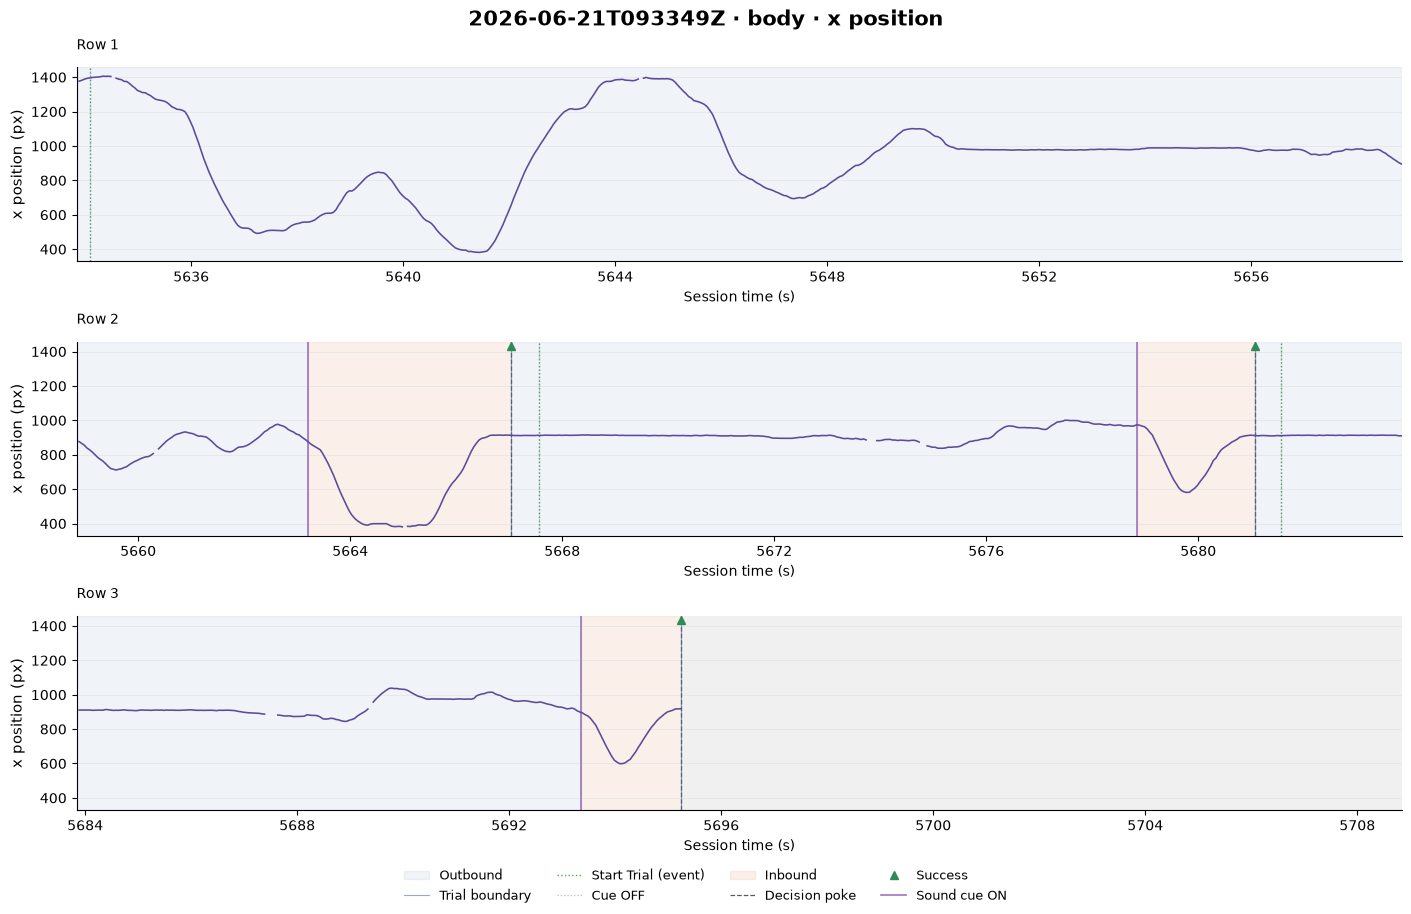

In [8]:
#=== 1| Plot x position as one continuous wrapped timeline ========
x_position_figure, x_position_axes = plot_wrapped_kinematic_trace(
    measurements["x_position"],
    trials,
    events,
    window=plot_window,
    row_duration_s=ROW_DURATION_S,
    ylabel="x position (px)",
    title=f"{SESSION} · {TRACKING_KEYPOINT} · x position",
    y_mode="data",
)
plt.show()


## y position


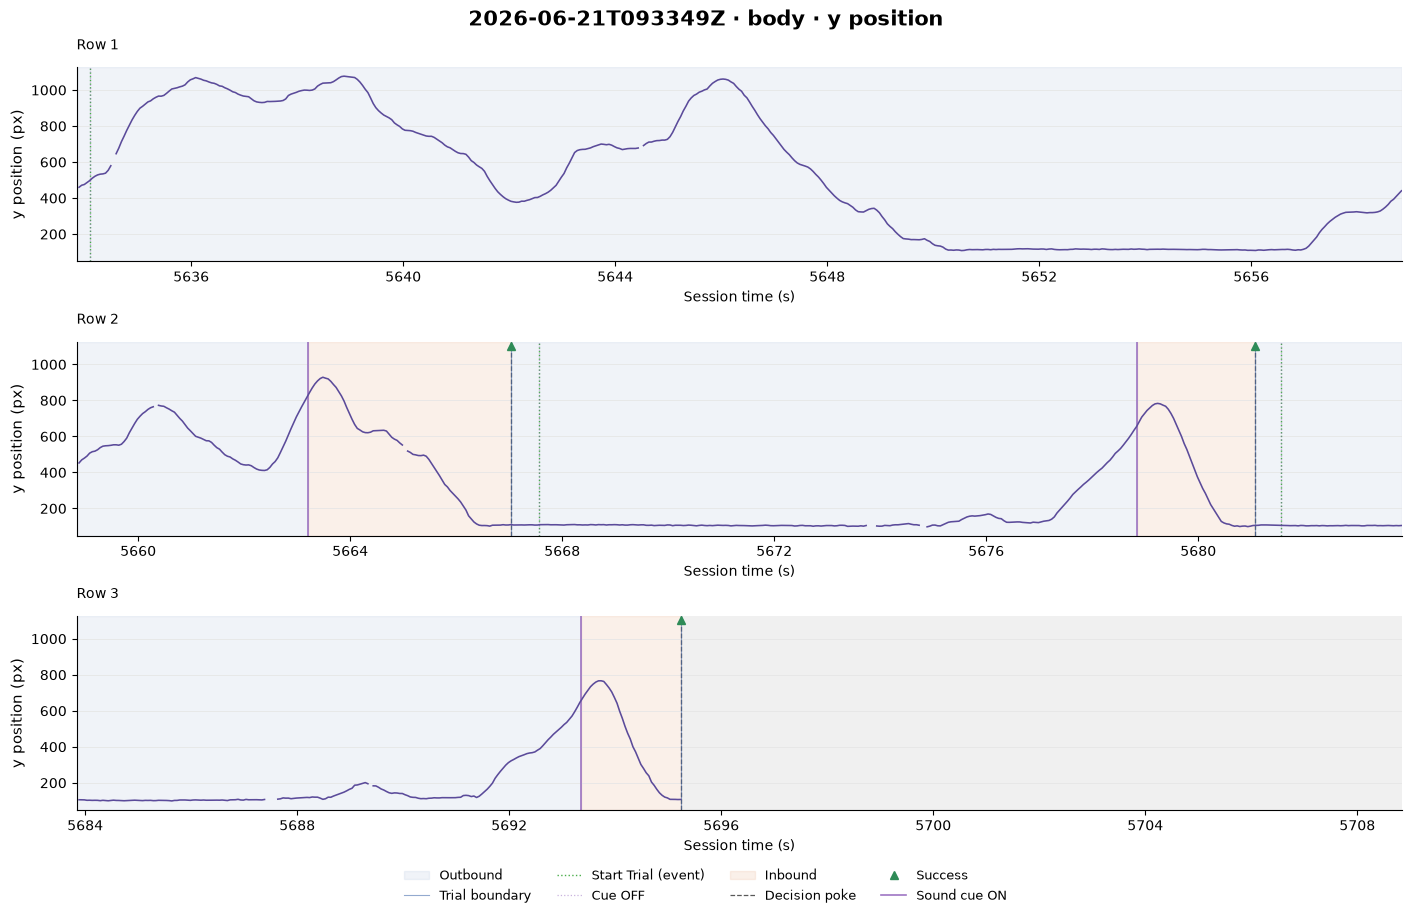

In [13]:
#=== 1| Plot y position as one continuous wrapped timeline ========
y_position_figure, y_position_axes = plot_wrapped_kinematic_trace(
    measurements["y_position"],
    trials,
    events,
    window=plot_window,
    row_duration_s=ROW_DURATION_S,
    ylabel="y position (px)",
    title=f"{SESSION} · {TRACKING_KEYPOINT} · y position",
    y_mode="data",
)
plt.show()


## Linear speed


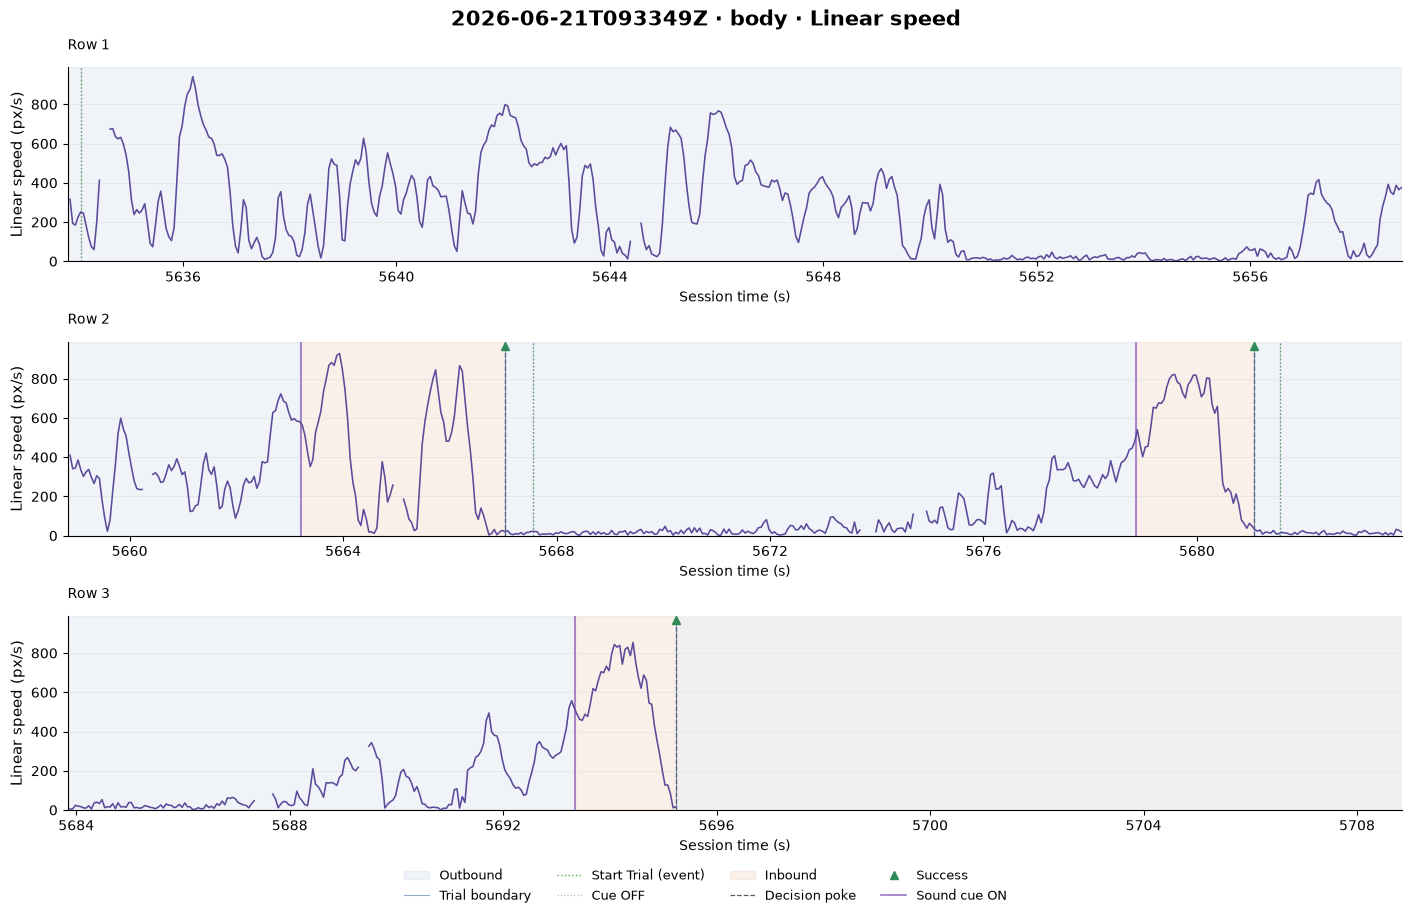

In [10]:
#=== 1| Plot linear speed as one continuous wrapped timeline ========
linear_speed_figure, linear_speed_axes = plot_wrapped_kinematic_trace(
    measurements["linear_speed"],
    trials,
    events,
    window=plot_window,
    row_duration_s=ROW_DURATION_S,
    ylabel="Linear speed (px/s)",
    title=f"{SESSION} · {TRACKING_KEYPOINT} · Linear speed",
    y_mode="nonnegative",
)
plt.show()


## Angular head velocity


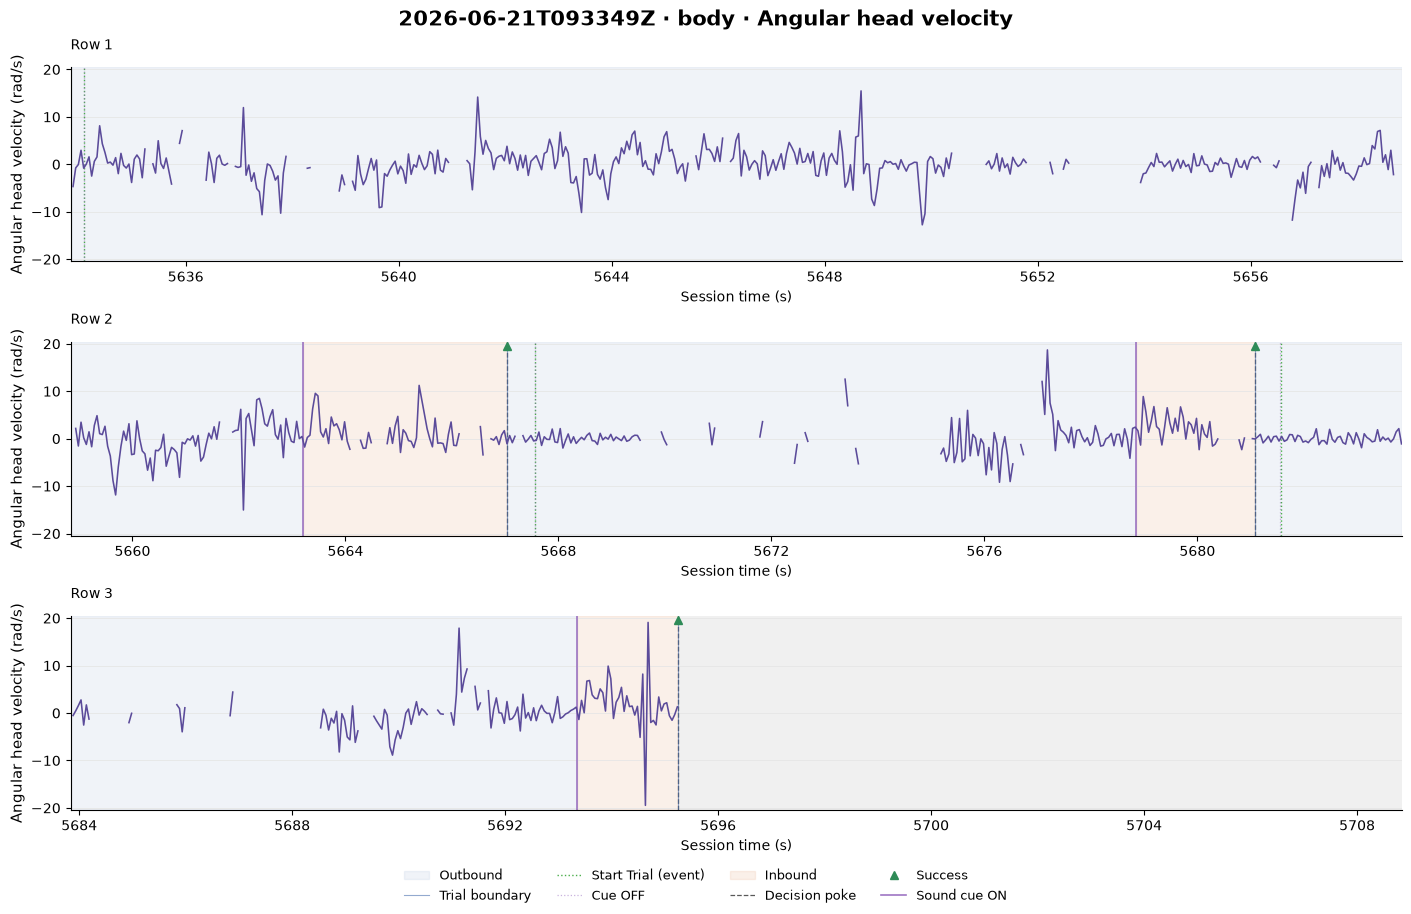

In [11]:
#=== 1| Plot angular head velocity as one continuous wrapped timeline ========
angular_head_velocity_figure, angular_head_velocity_axes = plot_wrapped_kinematic_trace(
    measurements["angular_head_velocity"],
    trials,
    events,
    window=plot_window,
    row_duration_s=ROW_DURATION_S,
    ylabel="Angular head velocity (rad/s)",
    title=f"{SESSION} · {TRACKING_KEYPOINT} · Angular head velocity",
    y_mode="symmetric",
)
plt.show()


API references: [speed](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_speed.html),
[head direction](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_head_direction_vector.html),
[signed angle](https://movement.neuroinformatics.dev/latest/api/movement.utils.vector.compute_signed_angle_2d.html).
Documentation may advance beyond the tested 0.17.0 version; record the version printed above.